## This task evaluates two execution algorithms, algo_1 and algo_2, using arrival slippage / IS slippage.
- Arrival slippage measures how the execution price compares to the market midpoint when the order first arrived. For a buy order, paying above the arrival mid is bad; for a sell order, selling below the arrival mid is bad.
- Lower slippage means better execution relative to the market mid-price when the order arrived. 

The goal is to compare raw performance and then assess performance after accounting for order difficulty.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("TCA_problem.csv")

# drop the extra index-like column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()

(40000, 7)


,IS_Slippage,ordersize,volatility,averageSpread,duration,notional,algo
0,118.374496,28.154509,150,2.638797,0.997847,1.981122e+08,algo_2
1,368.606221,193.324306,300,4.264819,1.000000,1.077540e+07,algo_2
2,356.180923,46.862604,300,1.954701,1.000000,2.647122e+07,algo_2
3,110.203046,49.780591,100,6.334067,0.941159,2.929402e+07,algo_1
4,-39.989627,7.890752,300,1.691854,1.000000,2.162974e+08,algo_2


In [122]:
print(df.describe())
print('-------------------------------------------------------------------------')
print()
print(df.isna().sum())
print('-----------------------------------------------------------------------------------------------------------------')

summary = df.groupby("algo").agg(
    n_orders=("IS_Slippage", "size"),
    mean_IS=("IS_Slippage", "mean"),
    median_IS=("IS_Slippage", "median"),
    std_IS=("IS_Slippage", "std"),
    mean_notional=("notional", "mean"),
    median_notional=("notional", "median"),
    mean_ordersize=("ordersize", "mean"),
    median_ordersize=("ordersize", "median"),
)
print()
print(summary)

        IS_Slippage     ordersize    volatility  averageSpread      duration  \
count  40000.000000  40000.000000  40000.000000   40000.000000  40000.000000   
mean     223.879454     72.099398    199.985000       4.432733      0.702325   
std      197.737593    114.586833     70.690344       5.727878      0.271583   
min     -450.978358      0.462115    100.000000       0.052149      0.000383   
25%       93.521857     16.664334    150.000000       1.367493      0.521417   
50%      187.259593     36.791575    200.000000       2.709871      0.772083   
75%      318.996357     82.278912    250.000000       5.242029      0.939186   
max     2433.721410   3286.605211    300.000000     172.026282      1.000000   

           notional  
count  4.000000e+04  
mean   3.434024e+07  
std    1.173464e+08  
min    8.166798e+04  
25%    1.023405e+07  
50%    2.027968e+07  
75%    3.968378e+07  
max    1.368619e+10  
-------------------------------------------------------------------------

IS_Sli

## 1. How would you compare the IS slippage of algo_1 and algo_2？Which one do you think performs better (smaller IS slippage)? Why?

- I first compare the two algos using average and median IS slippage.
- Since lower slippage is better, the algo with smaller mean/median appears better on a raw basis.
- I also examine the distribution because averages alone may be distorted by outliers or skew.

In [123]:
q1_stats = df.groupby("algo")["IS_Slippage"].agg(["count", "mean", "median", "std", "min", "max"])
print(q1_stats)

        count        mean      median         std         min          max
algo                                                                      
algo_1  20000  203.833125  172.713069  185.341458 -450.978358  1980.084979
algo_2  20000  243.925783  203.398346  207.477854 -423.340438  2433.721410


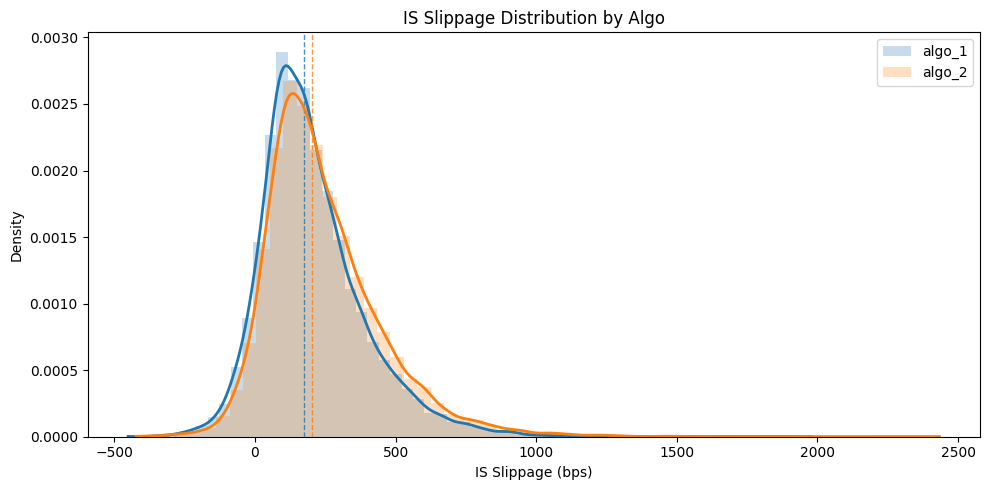

In [124]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10.colors  # up to 10 algos

for i, (algo_name, sub) in enumerate(df.groupby("algo")):
    data = sub["IS_Slippage"].dropna()
    color = colors[i % len(colors)]
    
    # Histogram (normalized to density so KDE is on same scale)
    ax.hist(data, bins=60, alpha=0.25, density=True, color=color, label=algo_name)
    
    # KDE overlay
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2)
    
    # Optional: mark the median
    ax.axvline(data.median(), color=color, linestyle="--", linewidth=1, alpha=0.8)

ax.set_xlabel("IS Slippage (bps)")
ax.set_ylabel("Density")
ax.set_title("IS Slippage Distribution by Algo")
ax.legend()
plt.tight_layout()
plt.show()

On a raw unconditional basis, **algo_1 appears to perform better**, having lower average and median IS slippage while also centering around this lower IS with smaller variance. However, **this comparison may not be fully fair** if the two algos are assigned different types of orders.

## 2. Compute the notional weighted IS slippage of both algos. How would you interpret this number? What is its economic interpretation? How would you measure a single order's contribution to the notional weighted average?

- The notional-weighted IS slippage measures execution cost per unit of traded money. 
- It is more economically meaningful than a simple average across orders because each order may be of different sizes of capital. Large orders represent more capital and therefore naturally should contribute more to the final performance measure. 
- A single order’s contribution equals its notional weight times its slippage.

In [125]:
df['algo_total_notional'] = df.groupby('algo')['notional'].transform('sum')
df['IS_weighted_contribution'] = df['IS_Slippage'] * df['notional'] / df['algo_total_notional']

df.head()

,IS_Slippage,ordersize,volatility,averageSpread,duration,notional,algo,algo_total_notional,IS_weighted_contribution
0,118.374496,28.154509,150,2.638797,0.997847,1.981122e+08,algo_2,7.164690e+11,0.032732
1,368.606221,193.324306,300,4.264819,1.000000,1.077540e+07,algo_2,7.164690e+11,0.005544
2,356.180923,46.862604,300,1.954701,1.000000,2.647122e+07,algo_2,7.164690e+11,0.013160
3,110.203046,49.780591,100,6.334067,0.941159,2.929402e+07,algo_1,6.571406e+11,0.004913
4,-39.989627,7.890752,300,1.691854,1.000000,2.162974e+08,algo_2,7.164690e+11,-0.012073


In [126]:
notional_weighted_summary = df.groupby('algo').agg(
    total_notional=('notional', 'sum'),
    notional_weighted_avg_IS_bps=('IS_weighted_contribution', 'sum'),
)
print(notional_weighted_summary)

        total_notional  notional_weighted_avg_IS_bps
algo                                                
algo_1    6.571406e+11                    207.300834
algo_2    7.164690e+11                    371.652034


The IS weighted contribution represents each trade's slippage scaled by the trade's notional relative to the algo's total notional. Thus, **the notional weighted average IS, the sum of the contributions, measures the average execution shortfall experienced by each dollar of traded notional**.

Both algos see an increase from its simple average IS to its notional weighted average IS. This points to the fact that **on larger orders (larger notional), the algos tend to have larger slippages**. This phenomenon is more pronounced in algo_2, as reflected by a much larger increase.

## 3. Plot and describe the disitrbution of the 'features'. i.e. Volatility, Average Spread, Order Size and Duration.

- Notionals/Trade volumes still may not tell the whole story since the algos may be assigned orders of different difficulties, which can be reflected via 'features'.

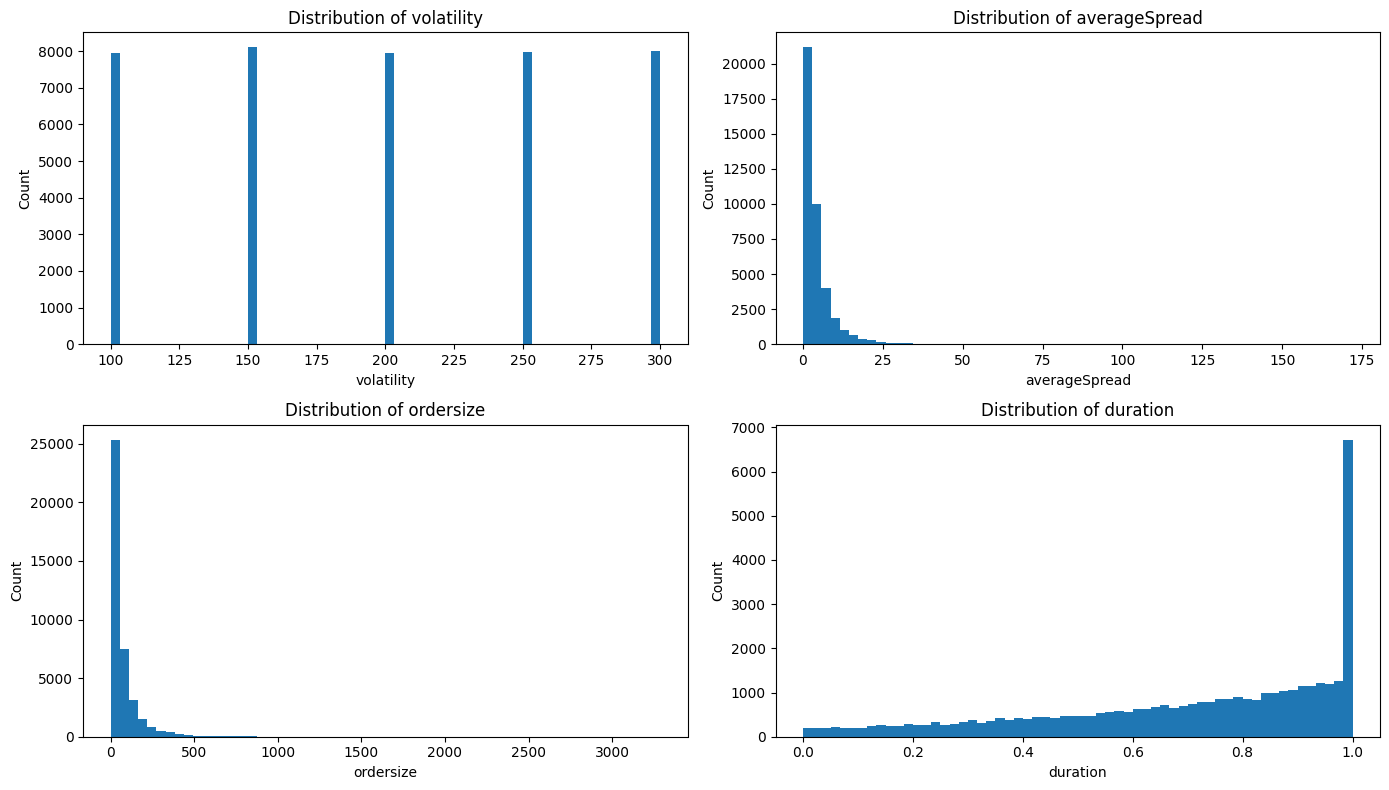

In [127]:
features = ["volatility", "averageSpread", "ordersize", "duration"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    ax.hist(df[feat], bins=60)
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

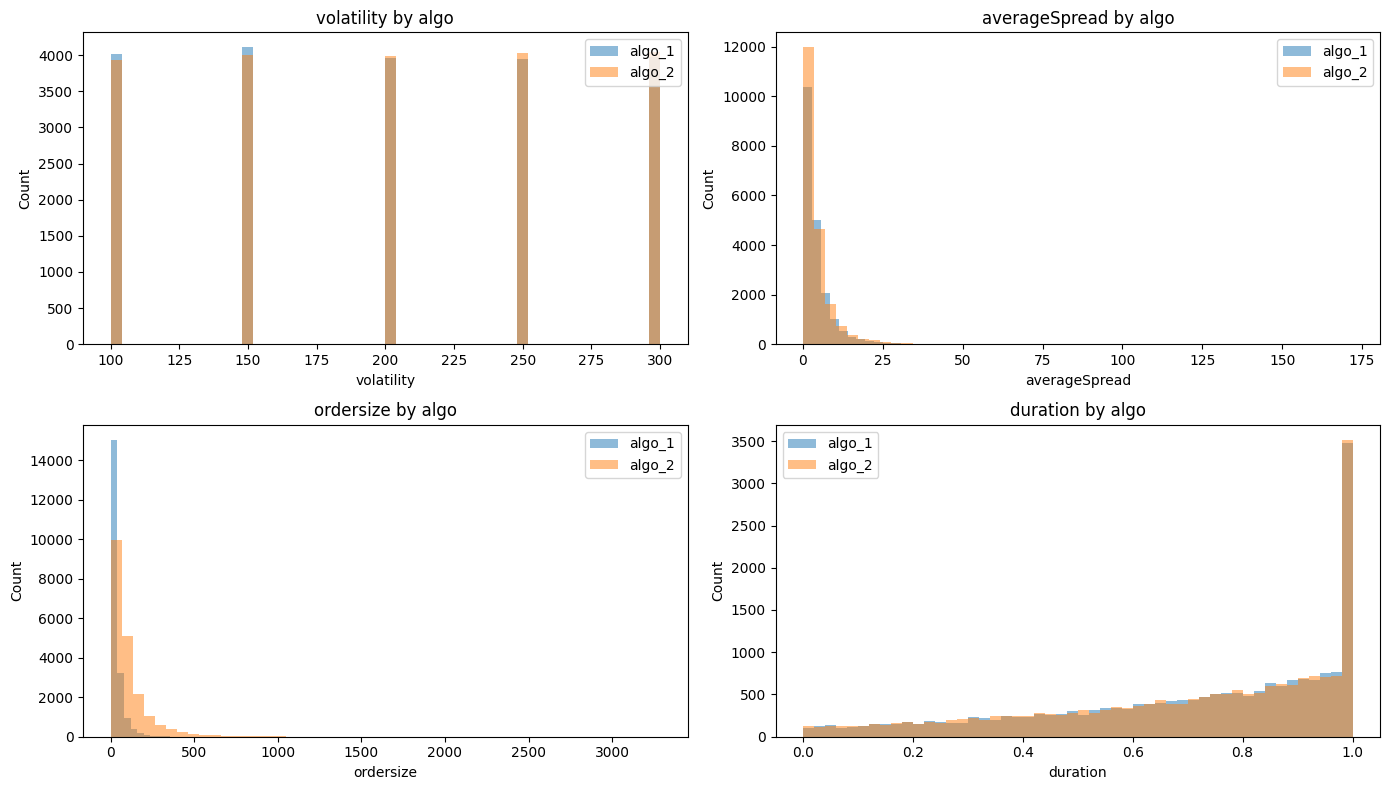

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for algo_name, sub in df.groupby("algo"):
        ax.hist(sub[feat], bins=50, alpha=0.5, label=algo_name)
    ax.set_title(f"{feat} by algo")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [129]:
feature_summary = df.groupby("algo")[features].agg(["mean", "median", "std"])
print(feature_summary)

       volatility                   averageSpread                      \
             mean median        std          mean    median       std   
algo                                                                    
algo_1   199.3625  200.0  70.717527      4.417685  2.706195  5.611367   
algo_2   200.6075  200.0  70.659434      4.447781  2.713522  5.842168   

         ordersize                         duration                      
              mean     median         std      mean    median       std  
algo                                                                     
algo_1   33.547108  20.558415   44.556685  0.704094  0.773792  0.270464  
algo_2  110.651687  67.064684  145.955255  0.700557  0.770492  0.272693  


Volatility is **relatively uniform across the two algos**, though algo_2 takes on slightly more highly-volatile orders. There is not a lot of variation in volatility values as this measure is discrete and can only take one of five possible values.

Average spread shows a similar right-skewed distribution for both algos, though **algo_2 has a slightly fatter tail of less liquid orders**. The mid-price normalized spread has a median of close to 3 bps.

Order size shows a right-skewed distribution, and **algo_2 has a considerably fatter tail of large orders**. algo_2 tends to handle materially larger orders, with both its mean and median order size several times larger than algo_1's.

Duration shows a similar left-skewed distribution for both algos, with **a significant proportion of orders lasting almost a full day**. The median order lasts around three quarters of a trading day.

Therefore, algo_2's worse slippage can be largely attributed to the nature of the orders it receives. **algo_2 is systematically assigned larger orders in less liquid names — both of which are well-known drivers of execution shortfall**. It handles a structurally harder flow than algo_1, which makes a raw slippage comparison between the two misleading without controlling for order difficulty.

## 4. What do you think is the relationship between the features and IS slippage? (You could start with monotonicity) Model IS slippage as a random variable whose parameters depend on the features. Explain how you determine your model.

## 5. Fit your model if possible. How would you interpret your fitting results? Which algo do you think is better? Why?

## 6. What if some orders are partially filled? (Hint: Construct an algo that may not fully fill but always beats arrival mid) How would you compare two algos when one algo requires fully fill while the other does not?

## 7. Describe how you would tackle this problem if you have access to more features. What features do you think might help?

I'm available for the internship starting June 1st to September 26th and can come to office 5 days/week. Thank you!